In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATASET_PATH = Path('Dataset')

!ls {DATASET_PATH}

cashflow_monthly.csv	      labour_monthly.csv
commodity_prices_monthly.csv  operating_costs_monthly.csv
ingredient_usage_monthly.csv  sales_daily.csv


# Exploratory Data Analysis

## Sales Daily

In [2]:
sales_daily = pd.read_csv(
    DATASET_PATH / 'sales_daily.csv',
    parse_dates=True,
    index_col='date',
)

print(sales_daily.info())
print(sales_daily.head())

<class 'pandas.DataFrame'>
DatetimeIndex: 7304 entries, 2019-01-01 to 2023-12-31
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product         7304 non-null   str    
 1   units_sold      7304 non-null   int64  
 2   unit_price_usd  7304 non-null   float64
 3   revenue_usd     7304 non-null   float64
dtypes: float64(2), int64(1), str(1)
memory usage: 285.3 KB
None
             product  units_sold  unit_price_usd  revenue_usd
date                                                         
2019-01-01     bread          62            3.53       219.17
2019-01-01  pastries          94            2.84       266.83
2019-01-01     cakes          11           18.21       200.28
2019-01-01    coffee          74            3.18       235.53
2019-01-02     bread          66            3.44       226.81


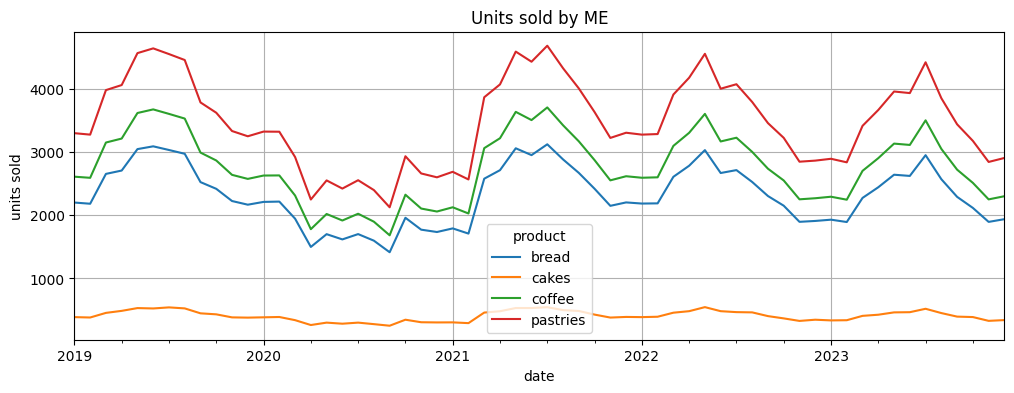

In [3]:
freq = 'ME'

(
    sales_daily
        .groupby('product')['units_sold']
        .resample(freq)
        .sum()
        .unstack(level='product')
).plot(
    figsize=(12, 4),
    title=f'Units sold by {freq}',
    ylabel='units sold',
    grid=True
);

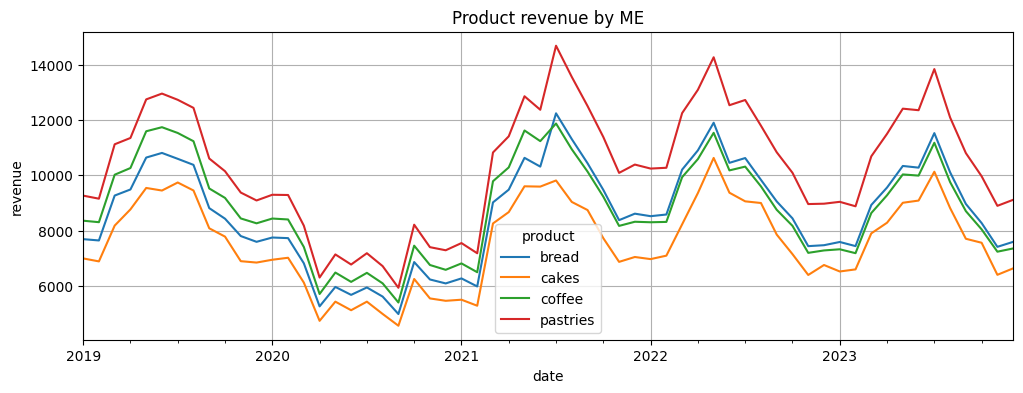

In [4]:
(
    sales_daily
        .groupby('product')['revenue_usd']
        .resample(freq)
        .sum()
        .unstack(level='product')
).plot(
    figsize=(12, 4),
    ylabel='revenue',
    title=f'Product revenue by {freq}',
    grid=True,
);

**Sales Daily: Insights**
* dataset likely corresponds to a bakery
* bakery sells bread, cakes, coffeee and pastries
* all products seems to have a consistent seasonal trend
* something happened in 2020 that drove the sales down
* pastries are the most requested product and contributes the greater to revenues
* cakes are not so popular, however, its revenue is not negligible

## Labour Monthly

In [5]:
labour_monthly = pd.read_csv(
    DATASET_PATH / 'labour_monthly.csv',
    parse_dates=True,
    index_col='month',
)

print(labour_monthly.info())
print(labour_monthly.head())
print(labour_monthly.tail())

<class 'pandas.DataFrame'>
DatetimeIndex: 240 entries, 2019-01-01 to 2023-12-01
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   role                   240 non-null    str    
 1   headcount              240 non-null    int64  
 2   hours_worked           240 non-null    int64  
 3   hourly_wage_usd        240 non-null    float64
 4   total_labour_cost_usd  240 non-null    float64
dtypes: float64(2), int64(2), str(1)
memory usage: 11.2 KB
None
                      role  headcount  hours_worked  hourly_wage_usd  \
month                                                                  
2019-01-01  baker_fulltime          2           160             18.0   
2019-01-01  baker_parttime          3            64             15.0   
2019-01-01         cashier          2            80             14.0   
2019-01-01         manager          1           160             28.0   
2019-02-01  baker_fulltime  

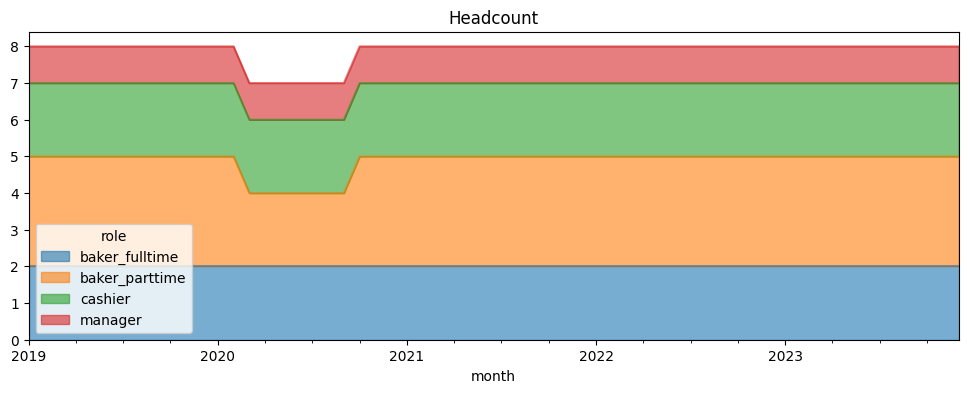

In [6]:
labour_monthly.pivot_table(
    index='month',
    columns='role',
    values='headcount',
    aggfunc='sum',
).plot(
    figsize=(12, 4),
    kind='area',
    alpha=0.6,
    title='Headcount',
);

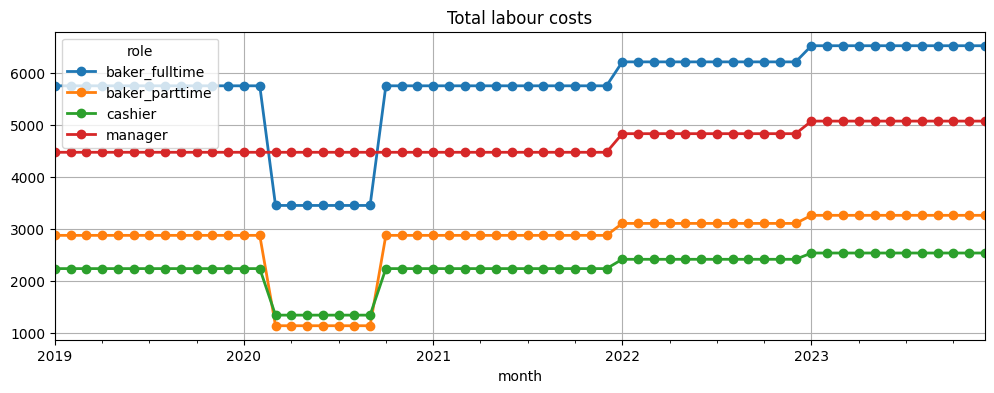

In [7]:
labour_monthly.pivot_table(
    index='month',
    columns='role',
    values='total_labour_cost_usd',
    aggfunc='sum',
).plot(
    figsize=(12, 4),
    title='Total labour costs',
    linewidth=2,
    style='-o',
    grid=True,
);

**Labour Monthly: Insights**
* bakery usually emplois 8 workers (including the manager). Each role is filled approximately by two persons (there are usually three parttimers).
* Even though a "crisis" was around in 2020, only one parttimer was laid off.
* In the 2020 event, total labour costs in each role were reduced by half, except for the manager.

## Operating Costs Monthly

In [8]:
operating_costs_monthly = pd.read_csv(
    DATASET_PATH / 'operating_costs_monthly.csv',
    parse_dates=True,
    index_col='month',
)

print(operating_costs_monthly.info())
print(operating_costs_monthly.head())
print(operating_costs_monthly.tail())

<class 'pandas.DataFrame'>
DatetimeIndex: 60 entries, 2019-01-01 to 2023-12-01
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rent_usd         60 non-null     float64
 1   energy_usd       60 non-null     float64
 2   packaging_usd    60 non-null     float64
 3   maintenance_usd  60 non-null     float64
 4   insurance_usd    60 non-null     float64
 5   misc_usd         60 non-null     float64
dtypes: float64(6)
memory usage: 3.3 KB
None
            rent_usd  energy_usd  packaging_usd  maintenance_usd  \
month                                                              
2019-01-01    3800.0      597.77         324.36           175.30   
2019-02-01    3800.0      583.51         362.03           142.78   
2019-03-01    3800.0      555.87         308.29            85.26   
2019-04-01    3800.0      533.35         367.56            87.01   
2019-05-01    3800.0      549.82         359.70            84.94   


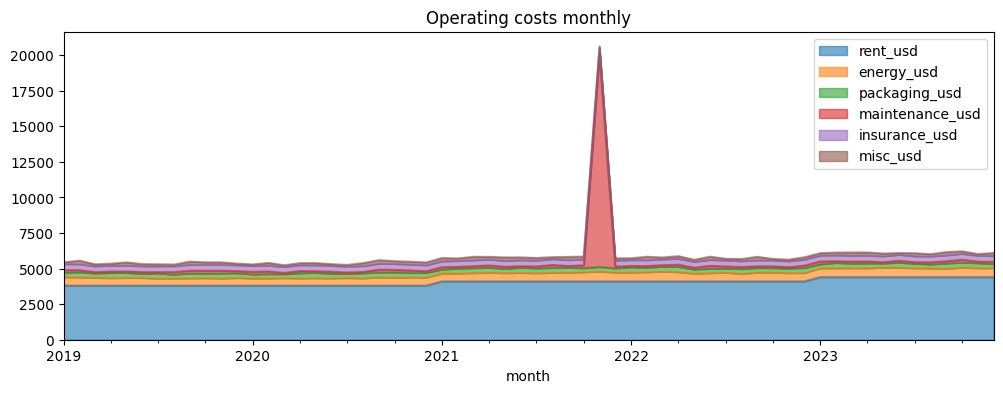

In [9]:
operating_costs_monthly.plot(
    figsize=(12, 4),
    kind='area',
    alpha=0.6,
    title='Operating costs monthly',
);

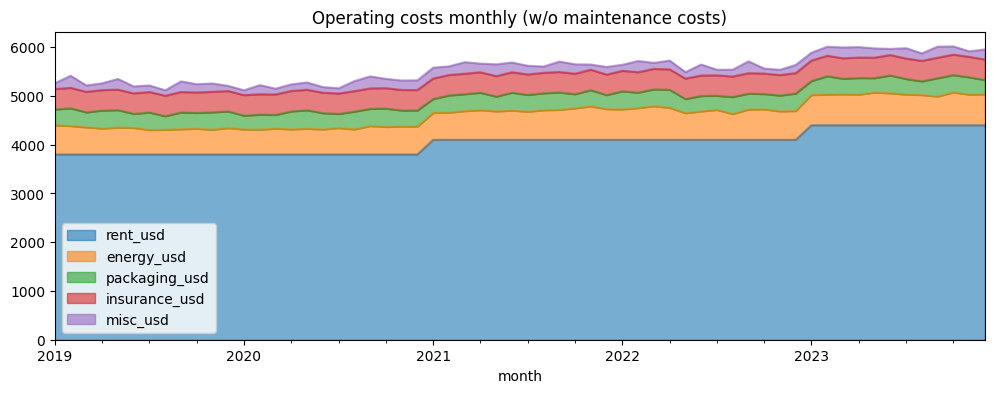

In [10]:
operating_costs_monthly.drop(columns=['maintenance_usd']).plot(
    figsize=(12, 4),
    kind='area',
    alpha=0.6,
    title='Operating costs monthly (w/o maintenance costs)',
);

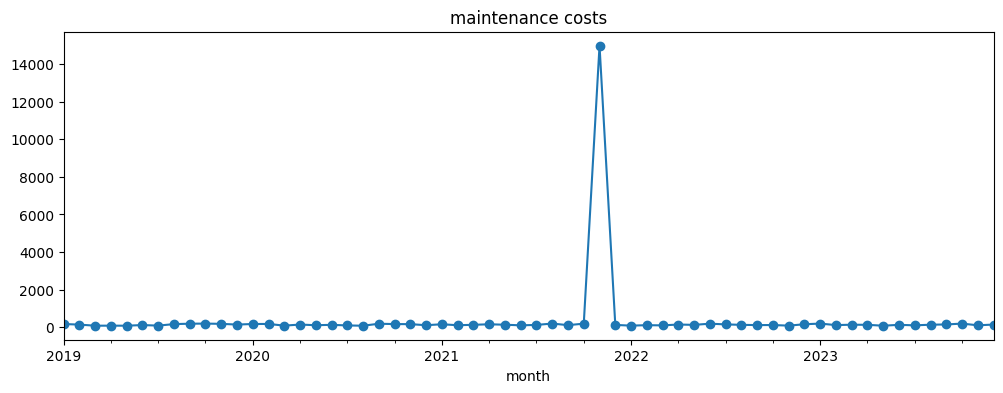

In [11]:
operating_costs_monthly['maintenance_usd'].plot(
    figsize=(12, 4),
    style='-o',
    title='maintenance costs',
);

**Operating Costs Monthly: Insights**
* rent is the most expensive operational cost (roughly 4k usd), maintenance is the cheapest at around 100usd.
* a huge peak in maintenance cost (up to 14k usd) is present at the end of 2022, further investigation is needed to discriminate between a typo and an actual event.
* operational costs were not affected in the 2020 event, hinting that low sales in that period can be attribute it to a change in preferences of the clients.

## Commodity Prices Monthly & Ingredient Usage Monthly

In [12]:
commodity_prices_monthly = pd.read_csv(
    DATASET_PATH / 'commodity_prices_monthly.csv',
    parse_dates=True,
    index_col='month',
)

print(commodity_prices_monthly.info())
print(commodity_prices_monthly.head())
print(commodity_prices_monthly.tail())

<class 'pandas.DataFrame'>
DatetimeIndex: 60 entries, 2019-01-01 to 2023-12-01
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   flour_usd_per_kg    60 non-null     float64
 1   butter_usd_per_kg   60 non-null     float64
 2   eggs_usd_per_unit   60 non-null     float64
 3   sugar_usd_per_kg    60 non-null     float64
 4   energy_usd_per_kwh  60 non-null     float64
dtypes: float64(5)
memory usage: 2.8 KB
None
            flour_usd_per_kg  butter_usd_per_kg  eggs_usd_per_unit  \
month                                                                
2019-01-01            0.5500             4.2000             0.2200   
2019-02-01            0.5677             4.5437             0.2206   
2019-03-01            0.5874             4.4197             0.2289   
2019-04-01            0.5863             4.4692             0.2220   
2019-05-01            0.5732             4.4778             0.2285   

          

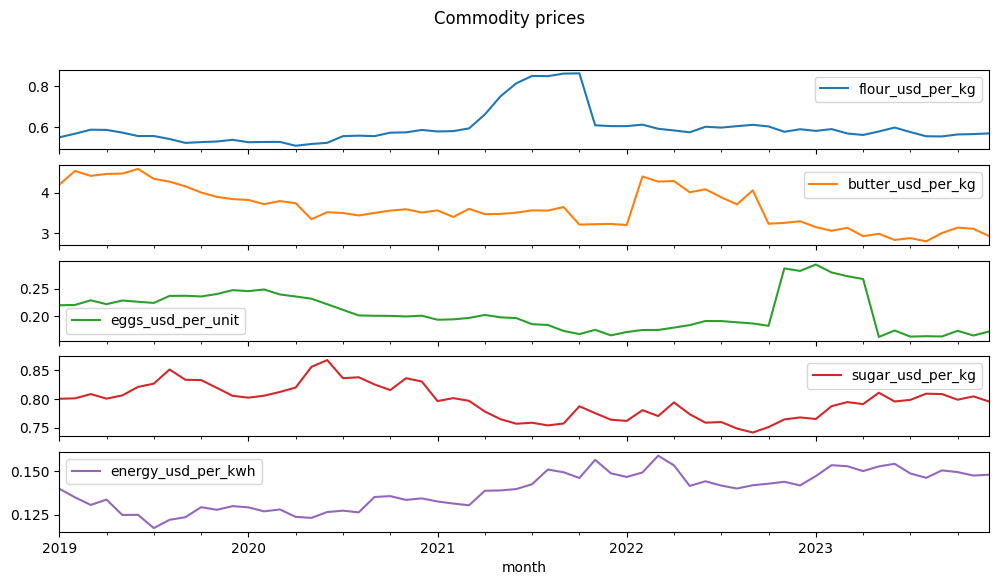

In [13]:
commodity_prices_monthly.plot(
    figsize=(12, 6),
    subplots=True,
    title='Commodity prices',
);

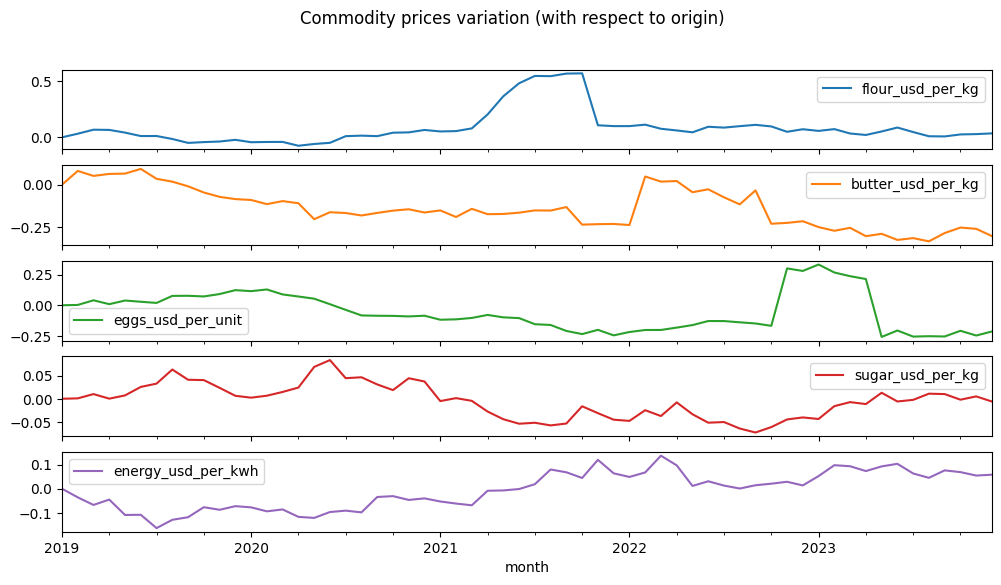

In [14]:
(
    commodity_prices_monthly / commodity_prices_monthly.iloc[0] - 1
).plot(
    figsize=(12, 6),
    subplots=True,
    title='Commodity prices variation (with respect to origin)',
);

In [15]:
ingredient_usage_monthly = pd.read_csv(
    DATASET_PATH / 'ingredient_usage_monthly.csv',
    parse_dates=True,
    index_col='month',
)

print(ingredient_usage_monthly.info())
print(ingredient_usage_monthly.head())
print(ingredient_usage_monthly.tail())

<class 'pandas.DataFrame'>
DatetimeIndex: 60 entries, 2019-01-01 to 2023-12-01
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   flour_kg                   60 non-null     float64
 1   butter_kg                  60 non-null     float64
 2   eggs_units                 60 non-null     float64
 3   sugar_kg                   60 non-null     float64
 4   total_ingredient_cost_usd  60 non-null     float64
dtypes: float64(5)
memory usage: 2.8 KB
None
            flour_kg  butter_kg  eggs_units  sugar_kg  \
month                                                   
2019-01-01    1320.8      341.4      2179.0     455.5   
2019-02-01    1309.0      338.3      2155.0     451.2   
2019-03-01    1587.9      409.3      2596.0     545.6   
2019-04-01    1628.9      422.1      2706.0     563.4   
2019-05-01    1825.7      471.3      3001.0     628.6   

            total_ingredient_cost_usd  
month       

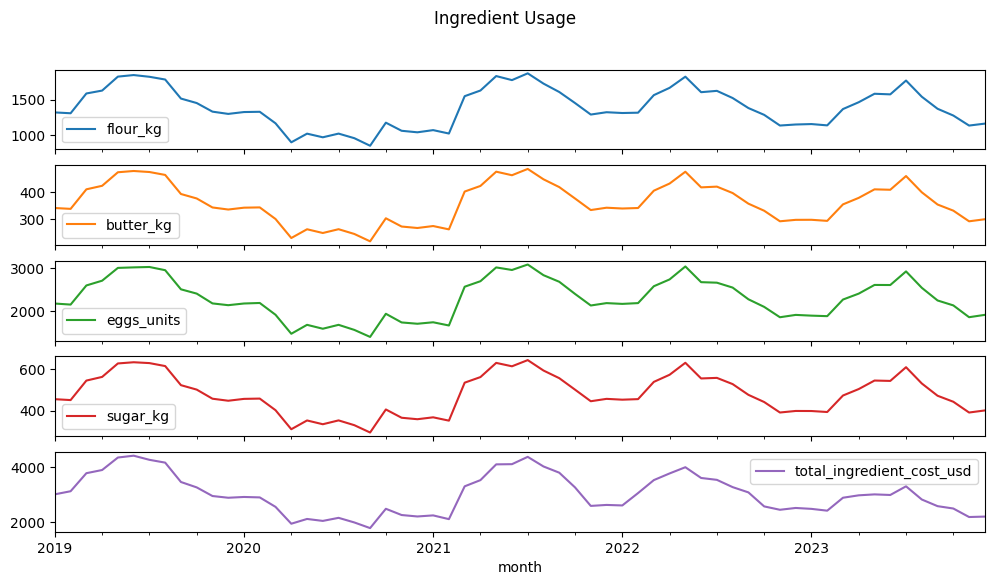

In [16]:
ingredient_usage_monthly.plot(
    figsize=(12, 6),
    subplots=True,
    title='Ingredient Usage',
);

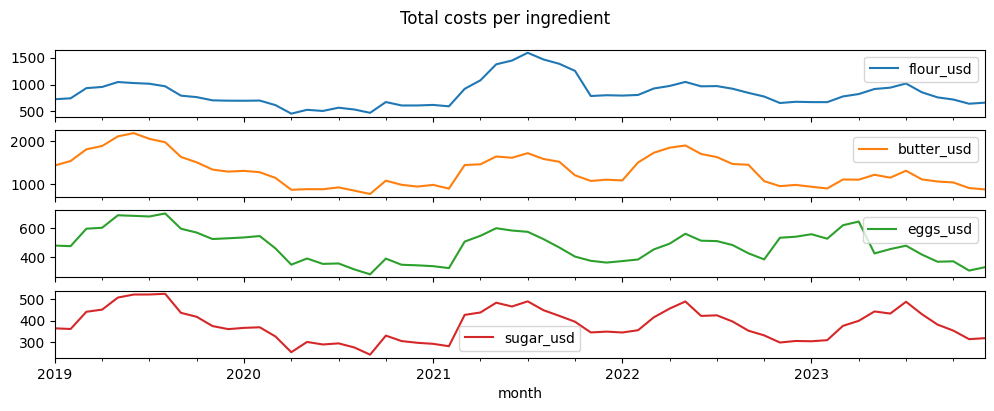

In [17]:
(
    commodity_prices_monthly.iloc[:, :-1]
    *
    ingredient_usage_monthly.iloc[:, :-1].values
).rename(columns={
    'flour_usd_per_kg': 'flour_usd',
    'butter_usd_per_kg': 'butter_usd',
    'eggs_usd_per_unit': 'eggs_usd',
    'sugar_usd_per_kg': 'sugar_usd',
}).plot(
    figsize=(12, 4),
    subplots=True,
    title='Total costs per ingredient',
);

**Commodity Prices Monthly & Ingredient Usage Monthly: Insights**
* Ingredients adquisition drops in 2020. Since prices didn't change, it's likely that the manager took a decision driven by internal factors.

## Cashflow Monthly

In [18]:
cashflow_monthly = pd.read_csv(
    DATASET_PATH / 'cashflow_monthly.csv',
    parse_dates=True,
    index_col='month'
)

print(cashflow_monthly.info())
print(cashflow_monthly.head())
print(cashflow_monthly.tail())

<class 'pandas.DataFrame'>
DatetimeIndex: 60 entries, 2019-01-01 to 2023-12-01
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   total_revenue_usd         60 non-null     float64
 1   ingredient_cost_usd       60 non-null     float64
 2   labour_cost_usd           60 non-null     float64
 3   fixed_operating_cost_usd  60 non-null     float64
 4   loan_payment_usd          60 non-null     float64
 5   interest_usd              60 non-null     float64
 6   total_costs_usd           60 non-null     float64
 7   net_cashflow_usd          60 non-null     float64
 8   cash_balance_usd          60 non-null     float64
 9   loan_balance_usd          60 non-null     float64
dtypes: float64(10)
memory usage: 5.2 KB
None
            total_revenue_usd  ingredient_cost_usd  labour_cost_usd  \
month                                                                 
2019-01-01           32302.25           

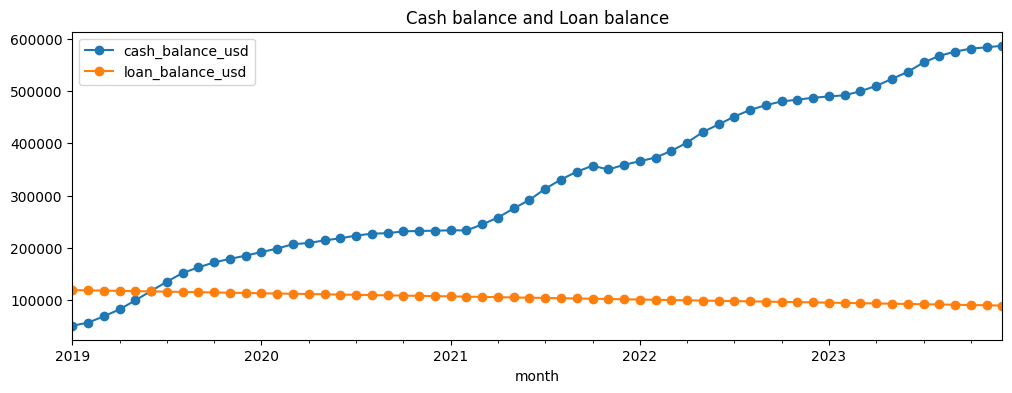

In [60]:
(
    cashflow_monthly[[
        'cash_balance_usd', 
        'loan_balance_usd',
    ]]
).plot(
    figsize=(12, 4),
    style='-o',
    title='Cash balance and Loan balance',
);

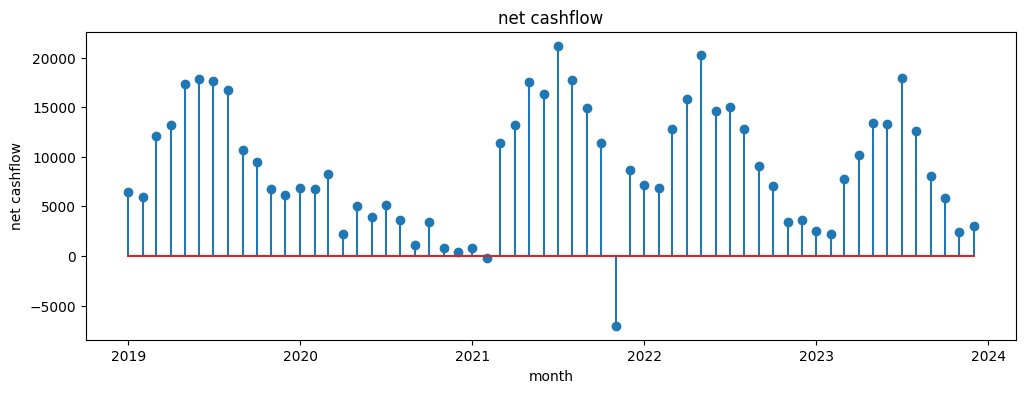

In [63]:
net_cashflow = cashflow_monthly['net_cashflow_usd']

plt.figure(figsize=(12, 4))
plt.title('net cashflow')
plt.stem(net_cashflow.index, net_cashflow)
plt.xlabel('month')
plt.ylabel('net cashflow')
plt.show()

**Cashflow Monthly: Insights**
* Loss is registered at the end of 2022, matching the high maintenance costs in that period.

## EDA Summary

In this section we present the overall picture of what we learned from data.



# Data Analysis

# Stress Testing